In [2]:
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path
sys.path.append('../results')

In [3]:
pkg_path = str(Path(os.path.abspath('')).parent.absolute())
sys.path.insert(0, pkg_path)
# print(pkg_path)
data_path=pkg_path+'/results/'

DSC_ED_file_name='shap_DSC_ap_rCBV_ED.csv'
DTI_NC_file_name='shap_DTI_AD_NC_.csv'
DTI_ET_file_name='shap_DTI_AD_ET_.csv'

shap_DSC=pd.read_csv(data_path+DSC_ED_file_name)
shap_DTI_NC=pd.read_csv(data_path+DTI_NC_file_name)
shap_DTI_ET=pd.read_csv(data_path+DTI_ET_file_name)


In [17]:

shap_DSC.sort_values(by='Summed_Shapy_Values',ascending=False, inplace=True)
shap_DTI_NC.sort_values(by='Summed_Shapy_Values',ascending=False, inplace=True)
shap_DTI_ET.sort_values(by='Summed_Shapy_Values',ascending=False, inplace=True)

shap_DSC['Unnamed: 0'] = shap_DSC['Unnamed: 0'].str.replace('DSC_ap-rCBV_ED_', '', regex=False)
shap_DTI_NC['Unnamed: 0'] = shap_DTI_NC['Unnamed: 0'].str.replace('DTI_AD_NC_', '', regex=False)
shap_DTI_ET['Unnamed: 0'] = shap_DTI_ET['Unnamed: 0'].str.replace('DTI_AD_ET_', '', regex=False)

shap_DTI_ET.head(10)

,Unnamed: 0,Summed_Shapy_Values
0,Morphologic_Flatness,1612.911059
1,Morphologic_Eccentricity,1595.964003
2,Histogram_Bins-16_Bins-16_Entropy,1152.128775
3,Intensity_Kurtosis,1028.600478
4,Histogram_Bins-16_Bins-16_InterQuartileRange,1008.758655
5,Intensity_Mean,892.668881
6,Intensity_InterQuartileRange,853.361846
7,Histogram_Bins-16_Bins-16_Bin-6_Probability,848.703300
8,Intensity_Minimum,823.476121
9,Morphologic_EllipseDiameter_Axis-2,745.756904


In [ ]:

# Cutoff determines the shap values in which to drop if beneath
cutoff=200

DTI_NC = shap_DTI_NC.reset_index()
DTI_ET = shap_DTI_ET.reset_index()

combined_df = pd.concat([DTI_NC, DTI_ET], axis=0)
combined_df.sort_values(by='Summed_Shapy_Values', ascending=False, inplace=True)
# Uncommenting will show that top features
combined_df= pd.DataFrame(combined_df[~combined_df.index.duplicated(keep='first')])

DTI_df = DTI_df = combined_df[combined_df['Summed_Shapy_Values'] >= cutoff]

DSC_df=shap_DSC[(shap_DSC['Summed_Shapy_Values']  >= cutoff)]

DSC_df.rename(columns={'Unnamed: 0': 'Selected_features'}, inplace=True)
DTI_df.rename(columns={'Unnamed: 0': 'Selected_features'}, inplace=True)

DTI_df2=DTI_df['Selected_features']
DSC_df2=DSC_df['Selected_features']

DSC_df.set_index('Selected_features', inplace=True)
DTI_df.set_index('Selected_features', inplace=True)

DSC_df=DSC_df['Summed_Shapy_Values']
DTI_df=DTI_df['Summed_Shapy_Values']

DTI_df.head()

/tmp/ipykernel_3937571/3564040409.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DSC_df.rename(columns={'Unnamed: 0': 'Selected_features'}, inplace=True)
/tmp/ipykernel_3937571/3564040409.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DTI_df.rename(columns={'Unnamed: 0': 'Selected_features'}, inplace=True)


Selected_features
Morphologic_Flatness                            1612.911059
Morphologic_Eccentricity                        1595.964003
Histogram_Bins-16_Bins-16_Entropy               1152.128775
Intensity_Kurtosis                              1028.600478
Histogram_Bins-16_Bins-16_InterQuartileRange    1008.758655
Name: Summed_Shapy_Values, dtype: float64

In [20]:
DTI_df2.to_csv(data_path+'selected_features_DTI.csv', header=True)
DSC_df2.to_csv(data_path+'selected_features_DSC.csv', header=True)

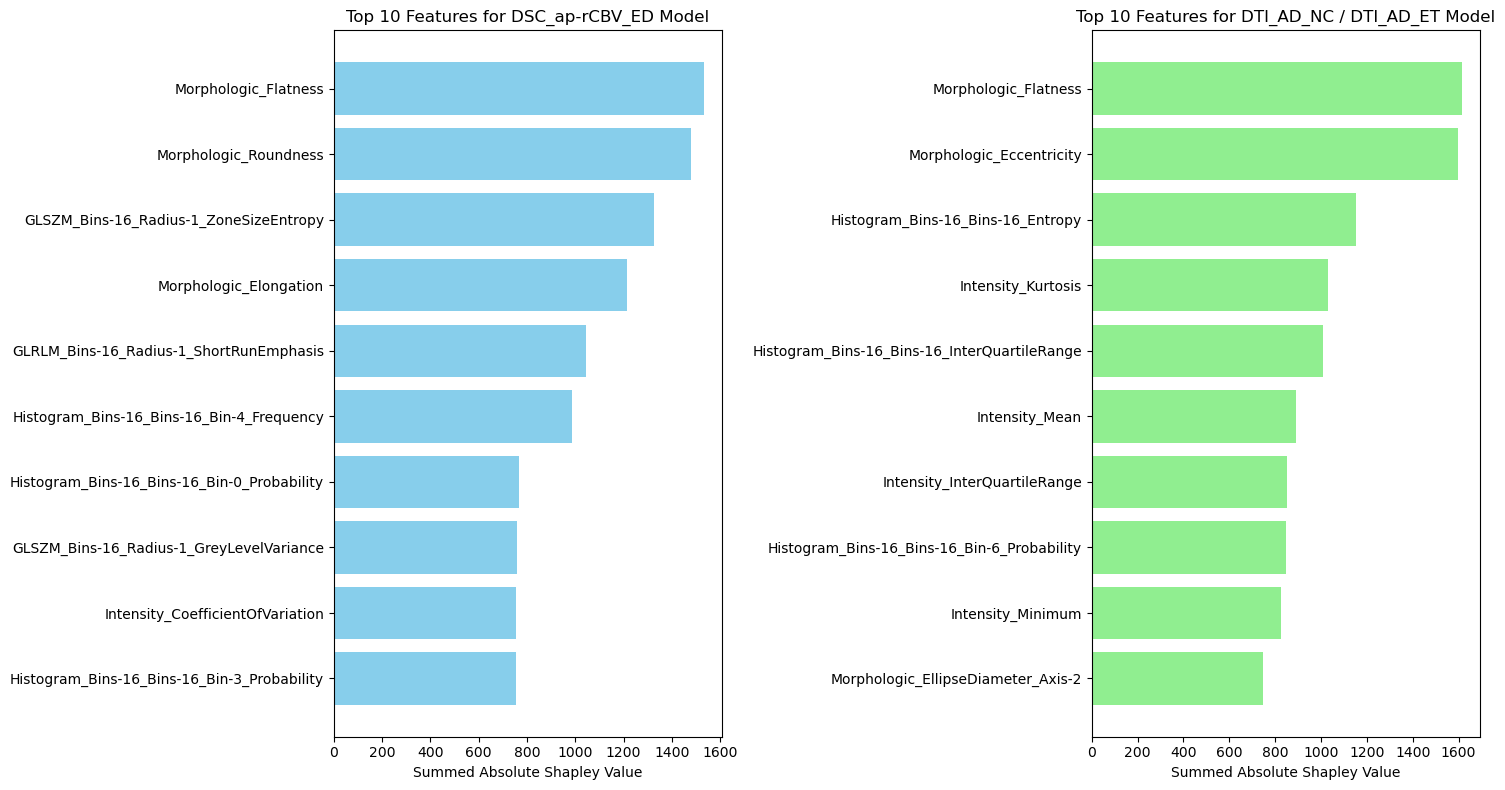

In [19]:
# Number of top features to display
num_top_features = 10

# Gets the top `num_top_features` features for DSC and DTI models based on the summed Shapley values
top_features_DSC = DSC_df.nlargest(num_top_features)
top_features_DTI = DTI_df.nlargest(num_top_features)

# Create subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Plot for DSC model
axes[0].barh(top_features_DSC.index, top_features_DSC.values, color='skyblue')
axes[0].set_xlabel('Summed Absolute Shapley Value')
axes[0].set_title(f'Top {num_top_features} Features for DSC_ap-rCBV_ED Model')
axes[0].invert_yaxis()  # Invert y-axis so that the highest values are at the top

# Plot for DTI model
axes[1].barh(top_features_DTI.index, top_features_DTI.values, color='lightgreen')
axes[1].set_xlabel('Summed Absolute Shapley Value')
axes[1].set_title(f'Top {num_top_features} Features for DTI_AD_NC / DTI_AD_ET Model')
axes[1].invert_yaxis()  # Invert y-axis so that the highest values are at the top
# Adjust layout and show the plot
plt.tight_layout()
plt.show()
